# Please install the following python libraries
- python3: https://www.python.org/
- numpy: https://numpy.org/install/
- tqdm: https://github.com/tqdm/tqdm#installation
- matplotlib: https://matplotlib.org/stable/users/installing/index.html
- Starter Code was tested on Python 3.11.11

If you encounter the error: "IProgress not found. Please update jupyter & ipywidgets"
    
Please install ipywidgets as follows:

    with uv, rerun jupyter-notebook via
    - `uvx --with numpy --with tqdm --with matplotlib --from notebook jupyter-notebook`
    with pip, do
    - `pip install ipywidgets`
    with conda, do
    - `conda install -c conda-forge ipywidgets`
    
Restart your notebook 

In [76]:
import numpy as np
import random
import tqdm.notebook as tqdm
import matplotlib.pyplot as plt
from typing import Tuple

In [77]:
"""Here is the implementation of the 10-armed Bandit problem/testbed. DO NOT CHANGE 
   Note that:
       - call the reset function whenever you want to generate a new 10-armed Bandit problem
"""
# @final
class Bandit:
    def __init__(self, k: int=10):
        """Create a k-armed bandit (see https://en.wikipedia.org/wiki/Slot_machine).
        
        Args:
            k: number of arms on the bandit
        """        
        self.k = k
        """Number of arms"""
        self.q_star = np.empty(self.k)
        """True arm values"""

    def reset(self):
        """Generates arm values creating a new bandit problem.

        Arm values are sampled from a normal distribution with mean=0.0 and variance=1.0
        """
        self.q_star = np.random.normal(loc=0, scale=1, size=self.k)
        
    def best_action(self):
        """Return the indices of all best actions/arms in a list variable"""
        return np.flatnonzero(self.q_star == self.q_star.max()).tolist()

    def step(self, act: int):
        """Samples a reward given an action.
        
        Args:
            act: index of the action
        """
        # Arm k: μ=q_star[k] σ=1.0
        return np.random.normal(self.q_star[act], 1.0)

In [78]:
"""Here is the plotting function you can directly use to plot the figures needed for Q2 and Q3
"""

# plot function
def plot_curves(arr_list: list[np.ndarray], legend_list: list[str], color_list: list[str], upper_bound: np.ndarray, ylabel: str):
    """
    Args:
        arr_list: list of results arrays to plot
        legend_list: list of legends corresponding to each result array
        color_list: list of colors corresponding to each result array
        upper_bound: array contains the best possible rewards for 2000 runs. the shape should be (2000,)
        ylabel: label of the Y axis
        
        Note that, make sure the elements in the arr_list, legend_list and color_list are associated with each other correctly. 
        Do not forget to change the ylabel for different plots.
        
        To plot the upper bound for % Optimal action figure, set upper_bound = np.ones(num_step), where num_step is the number of steps.
    """
    # set the figure type
    plt.clf()
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # PLEASE NOTE: Change the labels for different plots
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Steps")
    ax.set_ylim(-0.1, upper_bound.mean() + 0.1)
    
    # ploth results
    h_list = []
    for arr, legend, color in zip(arr_list, legend_list, color_list):
        # compute the standard error
        arr_err = arr.std(axis=0) / np.sqrt(arr.shape[0])
        # plot the mean
        h, = ax.plot(range(arr.shape[1]), arr.mean(axis=0), color=color, label=legend)
        # plot the confidence band
        arr_err = 1.96 * arr_err
        ax.fill_between(range(arr.shape[1]), arr.mean(axis=0) - arr_err, arr.mean(axis=0) + arr_err, alpha=0.3, color=color)
        # save the plot handle
        h_list.append(h) 
    
    # plot the upper bound
    h = plt.axhline(y=upper_bound.mean(), color='k', linestyle='--', label="upper bound")
    h_list.append(h)
    
    # plot legends
    ax.legend(handles=h_list)  
    plt.show()

# Q1: Implement 10-armed Bandit

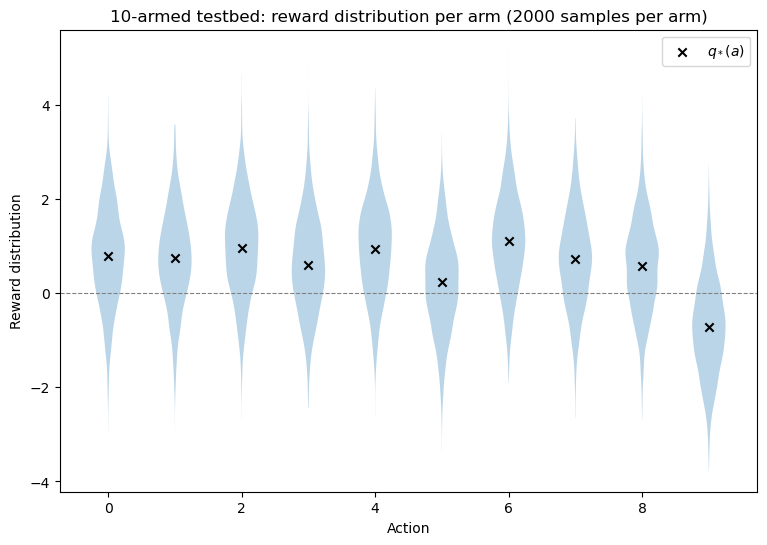

In [79]:
def MultiArmBandit(k: int, num_samples: int):
    """Q1

    Structure:
        1. Create multi-armed bandit env
        2. Pull each arm `num_samples` times and record the rewards
        3. Plot the rewards (e.g. violinplot, stripplot)

    Args:
        k: Number of arms in bandit environment
        num_samples: number of samples to take for each arm
    """


    env = Bandit(k=k)
    env.reset()

    q_value = []
    arm = []
    for action in range(k):
        for i in range(num_samples):
            # calculate the q_values for each action
            reward = env.step(action)   
            q_value.append(reward)
            # append the action to the arm 
            arm.append(action)

    return q_value, arm, env.q_star

k = 10
q_value, arm, q_star = MultiArmBandit(k=k, num_samples=2000)

q_value = np.array(q_value)
arm = np.array(arm)

grouped = [q_value[arm == a] for a in range(k)]

# create a violinplot
fig, ax = plt.subplots(figsize=(9, 6))
ax.violinplot(grouped, positions=range(k), showextrema=False)
# add q star x marker to the plot
ax.scatter(range(k), q_star, color="black", marker="x", zorder=3, label=r"$q_*(a)$")
# add axhline at zero reward
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

# labels
ax.set_xlabel("Action")
ax.set_ylabel("Reward distribution")

# title
ax.set_title(f"10-armed testbed: reward distribution per arm ({2000} samples per arm)")
ax.legend()
plt.show()

# Q2: Implement ε-greedy algorithm with incremental update

The following is the scaffolding code for the epsilon-greedy agent. 

    1. Reset function: reset the Q value for each arm/action to be self.init. (e.g., self.init = 0)
    
    2. Choose action: select the arm/action using epsilon-greedy strategy.
    
    3. Update: update the time steps, Q values for k arms/actions and numbers of selecting each arm/action.
    
    4. argmax: find the indices of all maximal values in a numpu array.
    
Please finish the code under "CODE HERE"

In [80]:
class EpsilonGreedyAgent(object):
    def __init__(self, k: int, init: float, epsilon: float) -> None:
        """Epsilon greedy bandit agent

        Args:
            k: number of arms
            init: initial value of Q-values
            epsilon: random action probability
        """
        # Number of the arms. For example, k = 10 for 10-armed Bandit problem
        self.k = k

        # Initial Q value
        self.init = init

        # Epsilon value
        self.epsilon = epsilon

        # Q-values for each arm
        self.Q = None
        # Number of times each arm was pulled
        self.N = None
        # Current total number of steps
        self.t = None

    def reset(self) -> None:
        """Initialize or reset Q-values and counts

        This method should be called after __init__() at least once
        """
        self.Q = self.init * np.ones(self.k, dtype=np.float32)
        self.N = np.zeros(self.k, dtype=int)
        self.t = 0

    def choose_action(self) -> int:
        """Choose which arm to pull

        With probability 1 - epsilon, choose the best action (break ties arbitrarily, use argmax() from above).
        
        With probability epsilon, choose a random action.
        """
        # obtain a random value from 0-1
        random_val = np.random.random()
        # check if that value is in epsilon for eg random_val = .95 and epslion is .9 we will explore
        if random_val < self.epsilon:
            return int(np.random.randint(self.k))
        else:
            return self.argmax(self.Q)

    def update(self, action: int, reward: float) -> None:
        """Update Q-values and N after observing reward.

        Args:
            action: index of pulled arm
            reward: reward obtained for pulling arm
        """
        # increase the time step
        self.t += 1
        
        # CODE HERE: implement the incremental update
        # update the self.N
        self.N[action] += 1
        
        # CODE HERE: update self.Q with the incremental update
        # Note: please use the sample-average technique in equation 2.1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


    @staticmethod
    def argmax(arr) -> int:
        """Argmax that breaks ties randomly

        Takes in a list of values and returns the index of the item with the highest value, breaking ties randomly.

        Note: np.argmax returns the first index that matches the maximum, so we define this method to use in EpsilonGreedy and UCB agents.
        Args:
            arr: sequence of values
        """
        #CODE HERE: implement argmax_a Q(a) for the greedy action selection, breaking ties randomly.
        # return int
        # So first we use numpy max to get the max, very importatnt when t=0 as steps go up they become 
        # very rare
        max_vals = np.max(arr)
        # now we create a boolean index where the indecies with the max values are true
        candidates = np.flatnonzero(arr == max_vals)
        # then return one of the indexes with the highest value, aka breaking ties randomly
        return int(np.random.choice(candidates))

In [81]:
""" Here is the function to run the epsilon greedy agent. Please complete the missing part under "CODE HERE"
"""
# run epsilon greedy 
def run_epsilon_greedy_agent(run_num: int, time_step: int, epsilon: float = 0.0, init: float = 0.0):
    """Run the epsilon greedy agent.
    
    Args:
        run_num: number of runs
        time_step: number of time steps per run
        epsilon: epsilon for the agent
        init: initial value for the Q. (i.e., Q1)
    """
    # DO NOT CHANGE: create the 10-armed Bandit problem
    k = 10
    env = Bandit(k)
    env.reset()

    # DO NOT CHANGE: create the agent with proper initial value and epsilon
    agent = EpsilonGreedyAgent(k=k, init=init, epsilon=epsilon)
    agent.reset()

    # DO NOT CHANGE: create a numpy array to store rewards with shape (run_num, time_step)
    # For example, results_rewards[r, t] stores the reward for step t in the r-th running trail
    results_rewards = np.empty((run_num, time_step))
    
    # DO NOT CHANGE: create a numpy array to store optimal action proportion with shape (run_num, time_step)
    # For example, results_action[r, t] stores 1 if the selected action at step t in the r-th runing trail is optimal
    # and 0 otherwise.
    results_action = np.empty((run_num, time_step))
    
    # DO NOT CHANGE: create a numpy array to save upper_bound (only for plotting rewards; it should be 1 for plotting action optimality proportion)
    # For example, upper_bound[r] stores the true action value for the r-th running trail.
    upper_bound = np.empty(run_num)
    

    # loop for trails starts
    for r in tqdm.tqdm(range(run_num), desc="run number", position=0):
        
        # CODE HERE: reset the environment to create a new 10-armed bandit problem.
        env.reset()

        # CODE HERE: reset the agent
        agent.reset()
        
        # CODE HERE: compute the upper bound for each running trial and update upper_bound[r]
        upper_bound[r] = env.q_star.max()

        # loop for each trail a fixed number of steps
        for t in tqdm.tqdm(range(time_step), desc="time step", position=1, leave=False):
            
            # CODE HERE: get the best action to execute at step t 
            # act = int
            act = agent.choose_action()
            
            # CODE HERE: interact with the environment to receive rewards
            # reward = float
            reward = env.step(act)
            
            # Code HERE: update the agent based on the observed reward
            agent.update(act, reward)

            """DO NOT CHANGE BELOW"""
            # save the reward
            results_rewards[r, t] = reward
            # check and save whether the action is optimal
            if act in env.best_action():
                results_action[r, t] = 1
            else:
                results_action[r, t] = 0
            
    return results_rewards, results_action, upper_bound

In [82]:
"""Here is the implementation for running the experiment. You have to run the "run_epsilon_greedy_agent" function
   for multiple times for different parameter combination. Please use smaller run_num and time_step for Debug only.
   For example, run_num = 100, time_step = 100
"""
# always set the random seed for results reproduction
np.random.seed(1234)
random.seed(1234)
    
# set the running parameters (Use 2000 runs and 1000 steps for final report)
run_num = 2000
time_step = 1000


# CODE HERE: 
# 1. run the epsilon-greedy agent experiment for initial value = 0.0, epsilon = 0.0

rewards0, actions0, upper_bound0 = run_epsilon_greedy_agent(run_num, time_step, 0.0, 0.0)
# 2. run the epsilon-greedy agent experiment for initial value = 0.0, epsilon = 0.01

rewards1, actions1, upper_bound1 = run_epsilon_greedy_agent(run_num, time_step, 0.01, 0.0)
# 3. run the epsilon-greedy agent experiment for initial value = 0.0, epsilon = 0.1

rewards2, actions2, upper_bound2 = run_epsilon_greedy_agent(run_num, time_step, 0.1, 0.0)

rewards_array_for_first_method = [rewards0, rewards1, rewards2]
action_array_for_first_method = [actions0, actions1, actions2]


run number:   0%|          | 0/2000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

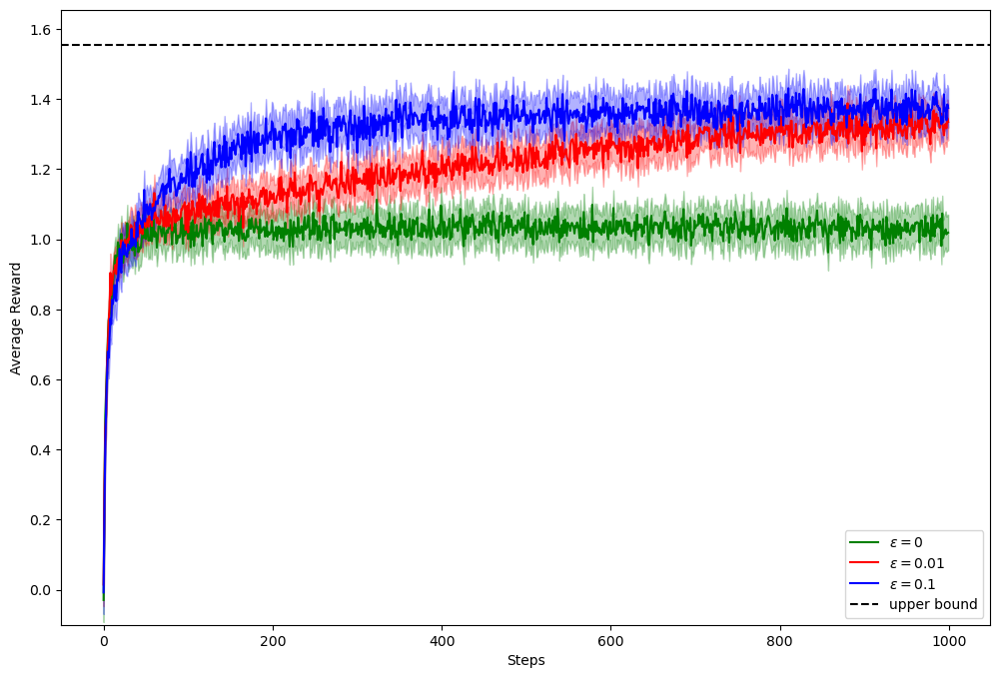

In [ ]:
# Plot the "Average reward" figure
# refer to https://matplotlib.org/stable/users/explain/text/mathtext.html for the labels i made
plot_curves( [rewards0, rewards1, rewards2],
            [r"$\epsilon=0$", r"$\epsilon=0.01$", r"$\epsilon=0.1$"],
            ["green", "red", "blue"],
            upper_bound0,
            "Average Reward")

<Figure size 640x480 with 0 Axes>

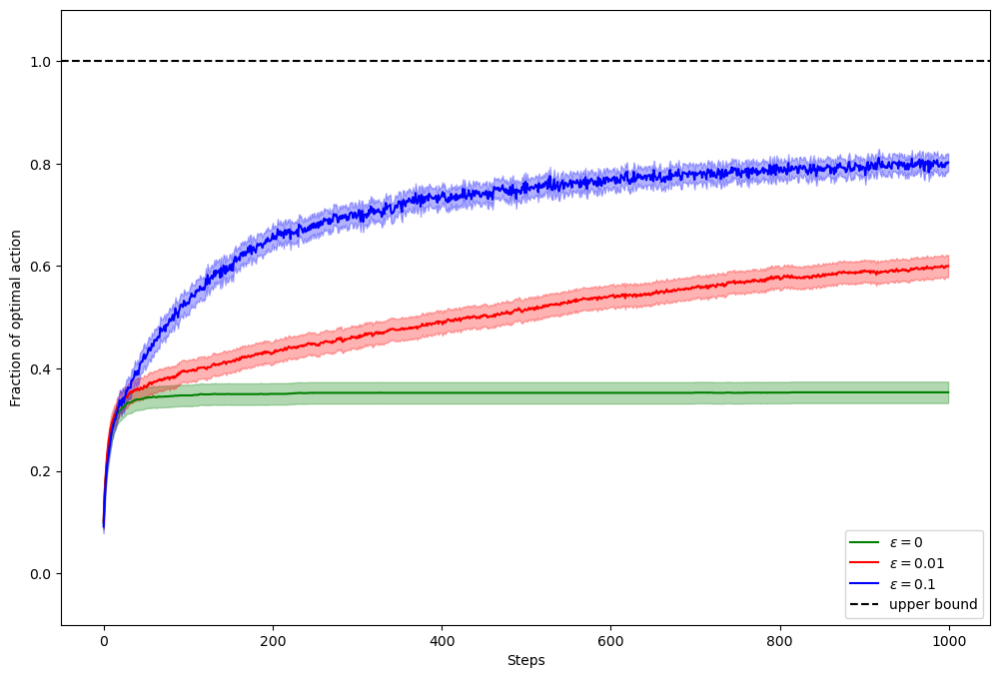

In [84]:
# Plot the "% Optimal action" figure
plot_curves(
    [actions0, actions1, actions2],
    [r"$\epsilon=0$", r"$\epsilon=0.01$", r"$\epsilon=0.1$"],
    ["green", "red", "blue"],
    np.ones(time_step),
    "Fraction of optimal action",
)

# Q3: Implement the ε-greedy algorithm with optimistic initial values, and the bandit algorithm with UCB action selection

In [ ]:
""" Reproducing the Figure 2.3.
Please note, instead of using the sample-average technique,
Use equation 2.5 to update the Q values with \alpha=0.1
"""
class EpsilonGreedyAgent:
    def __init__(self, k: int, init: float, epsilon: float) -> None:
        """Epsilon greedy bandit agent

        Args:
            k: number of arms
            init: initial value of Q-values
            epsilon: random action probability
        """
        # Number of the arms. For example, k = 10 for 10-armed Bandit problem
        self.k = k

        # Initial Q value
        self.init = init

        # Epsilon value
        self.epsilon = epsilon

        # Q-values for each arm
        self.Q = None
        # Number of times each arm was pulled
        self.N = None
        # Current total number of steps
        self.t = None

    def reset(self) -> None:
        """Initialize or reset Q-values and counts

        This method should be called after __init__() at least once
        """
        self.Q = self.init * np.ones(self.k, dtype=np.float32)
        self.N = np.zeros(self.k, dtype=int)
        self.t = 0

    def choose_action(self) -> int:
        """Choose which arm to pull

        With probability 1 - epsilon, choose the best action (break ties arbitrarily, use argmax() from above).
        
        With probability epsilon, choose a random action.
        """
        # obtain a random value from 0-1
        random_val = np.random.random()
        # check if that value is in epsilon for eg random_val = .95 and epslion is .9 we will explore
        if random_val < self.epsilon:
            return int(np.random.randint(self.k))
        else:
            return self.argmax(self.Q)


    def update(self, action: int, reward: float) -> None:
        """Update Q-values and N after observing reward.

        Args:
            action: index of pulled arm
            reward: reward obtained for pulling arm
        """
        # increase the time step
        self.t += 1
        
        # CODE HERE: implement the incremental update
        # update the self.N
        self.N[action] += 1

        # CODE HERE: update self.Q with the incremental update
        # Note: For reproducing Figure 2.3, implement the exponential average (equation 2.5)
        # Note: For reproducing Figure 2.4, implement the sample average (equation 2.1)
        if ALPHA is not None:
            # constant step size, eq 2.5 (Figure 2.3)
            step = ALPHA
        else:
            # sample average, eq 2.1 (Figure 2.4)
            step = 1 / self.N[action]

        # calculate the reward for a action and specific step
        self.Q[action] += step * (reward - self.Q[action])

    @staticmethod
    def argmax(arr: np.ndarray) -> int:
        """Argmax that breaks ties randomly

        Takes in a list of values and returns the index of the item with the highest value, breaking ties randomly.

        Note: np.argmax returns the first index that matches the maximum, so we define this method to use in EpsilonGreedy and UCB agents.
        Args:
            arr: sequence of values
        """
        # So first we use numpy max to get the max, very importatnt when t=0 as steps go up they become 
        # very rare
        max_vals = np.max(arr)
        # now we create a boolean index where the indecies with the max values are true
        candidates = np.flatnonzero(arr == max_vals)
        # then return one of the indexes with the highest value, aka breaking ties randomly
        return int(np.random.choice(candidates))

In [86]:
""" Here is the implementation of the UCB agent. Please complete the missing part.
"""
class UCBAgent:
    def __init__(self, k: int, init: float, c: float) -> None:
        """Create an upper confidence bound (UCB) Agent.

        Args:
            k: number of arms i.e. k=10 for the 10-armed Bandit problem
            init: initial value of Q-values
            c: UCB constant that controls degree of exploration
        """
        self.k = k
        self.init = init
        self.c = c

        # Q-values for each arm
        self.Q = None
        # Number of times each arm was pulled
        self.N = None
        # Current total number of steps
        self.t = None

    def reset(self) -> None:
        """Initialize or reset Q-values and counts.

        This method should be called after __init__() at least once
        """
        self.Q = self.init * np.ones(self.k, dtype=np.float32)
        self.N = np.zeros(self.k, dtype=int)
        self.t = 0

    def choose_action(self):
        """Choose which arm to pull.

        Use UCB action selection. Be sure to consider the case when N_t = 0 and break ties randomly (use argmax() from above)
        """
        # CODE HERE: use UCB to select the action. Be sure to consider the case when N_t = 0
        # and break ties randomly (use argmax() from above). The return should be an integer
        # index of the action.
        # return int
        untried = np.flatnonzero(self.N == 0)
        if untried.size > 0:
            return int(np.random.choice(untried))
        t = self.t + 1   # current step, 1-indexed like the book
        ucb = self.Q + self.c * np.sqrt(np.log(t) / self.N)
        return EpsilonGreedyAgent.argmax(ucb)



    def update(self, action: int, reward: float) -> None:
        """Update Q-values and N after observing reward.

        Args:
            action: index of pulled arm
            reward: reward obtained for pulling arm
        """
        # increase the time step
        self.t += 1

        # update self.N
        self.N[action] += 1

        if ALPHA is not None:
            # constant step size, eq 2.5 (Figure 2.3)
            step = ALPHA
        else:
            # sample average, eq 2.1 (Figure 2.4)
            step = 1 / self.N[action]

        self.Q[action] += step * (reward - self.Q[action])

In [87]:
"""Here is the implementation of running the UCB agent. Please complete the missing part.
"""
# run epsilon greedy 
def run_ucb_agent(run_num, time_step, c):
    # create the 10-armed Bandit problem
    k = 10
    env = Bandit(k)
    env.reset()

    # create the agent
    my_agent = UCBAgent(k=k, init=0.0, c=c)
    my_agent.reset()

    # create a numpy array
    results_rewards = np.empty((run_num, time_step))
    
    # create a numpy array
    results_action = np.empty((run_num, time_step))

    # loop starts
    upper_bound = np.empty(run_num)
    for r in tqdm.tqdm(range(run_num), desc="run number", position=0):
       
        # CODE HERE: reset the environment and the agent
        # create a new 10-armed bandit problem
        env.reset()
        
        # CODE HERE: create a new agent
        my_agent.reset()

        # CODE HERE: update upper_bound[r]
        upper_bound[r] = env.q_star.max()

        for t in tqdm.tqdm(range(time_step), desc="time step", position=1, leave=False):
            # CODE HERE: choose action for time step t
            # act = int
            act = my_agent.choose_action()

            # CODE HERE: interact with the environment
            # reward = float
            reward = env.step(act)

            # CODE HERE: update the bandit agent with the observed reward
            my_agent.update(act, reward)
            
            # save the reward
            results_rewards[r, t] = reward
            # compute the optimality
            if act in env.best_action():
                results_action[r, t] = 1
            else:
                results_action[r, t] = 0
            
    return results_rewards, results_action, upper_bound

# Reproduce Figure 2.3 using exponential average (equation 2.5 with alpha = 0.1)

In [88]:
"""Here is the implementation for running the experiment. You have to run the "run_ucb_agent" function
   for multiple times for different parameter combination. Please use smaller run_num and time_step for Debug only.
   For example, run_num = 100, time_step = 1000
"""
# set the running parameters
run_num = 2000 
time_step = 1000

# We set out alpha here
ALPHA = 0.1
    
# CODE HERE: 
# 1. Run the epsilon-greedy agent experiment for initial value = 0.0, epsilon = 0.0
rewards_a, actions_a, ub_a = run_epsilon_greedy_agent(run_num, time_step, 0.0, 0.0)
# 2. Run the epsilon-greedy agent experiment for initial value = 5.0, epsilon = 0.0 
rewards_b, actions_b, ub_b = run_epsilon_greedy_agent(run_num, time_step, 0.0, 5.0)
# 3. Run the epsilon-greedy agent experiment for initial value = 0.0, epsilon = 0.1 
rewards_c, actions_c, ub_c = run_epsilon_greedy_agent(run_num, time_step, 0.1, 0.0)
# 4. Run the epsilon-greedy agent experiment for initial value = 5.0, epsilon = 0.1 
rewards_d, actions_d, ub_d = run_epsilon_greedy_agent(run_num, time_step, 0.1, 5.0)
# 5. Run the UCB agent experiment for c=2
rewards_u, actions_u, ub_u = run_ucb_agent(run_num, time_step, 2.0)

run number:   0%|          | 0/2000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

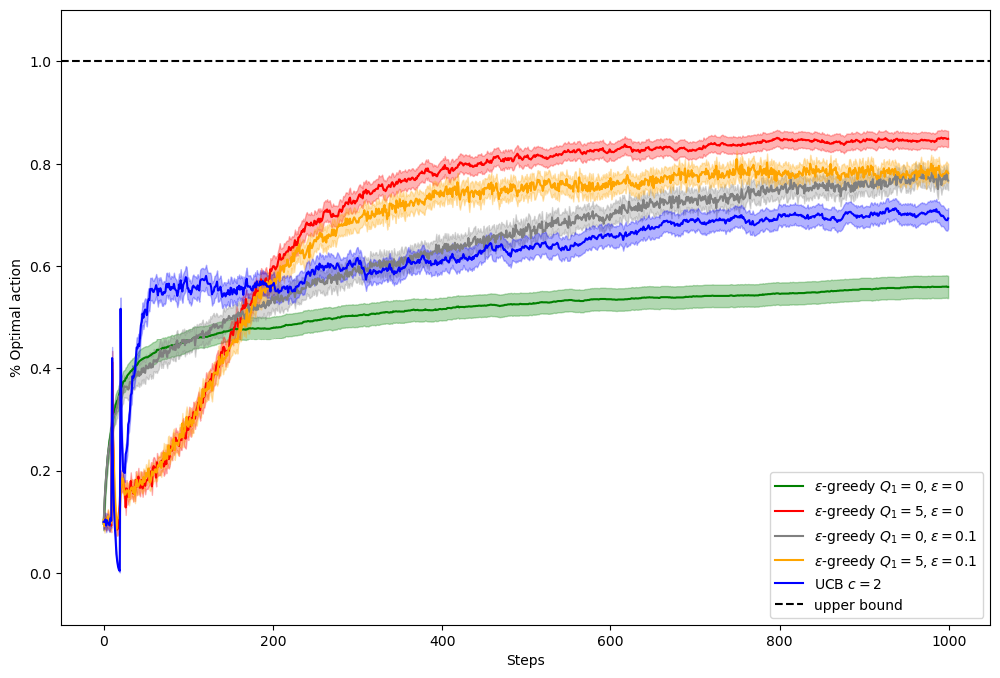

In [89]:
# Plot the "% Optimal action" figure
plot_curves([actions_a, actions_b, actions_c, actions_d, actions_u],
            [r"$\epsilon$-greedy $Q_1=0, \epsilon=0$",
             r"$\epsilon$-greedy $Q_1=5, \epsilon=0$",
             r"$\epsilon$-greedy $Q_1=0, \epsilon=0.1$",
             r"$\epsilon$-greedy $Q_1=5, \epsilon=0.1$",
             r"UCB $c=2$"],
            ["green", "red", "gray", "orange", "blue"],
            np.ones(time_step),
            "% Optimal action")

# Reproduce Figure 2.4 using sample average (equation 2.1)

In [90]:
"""Here is the implementation for running the experiment. You have to run the "run_ucb_agent" function
   for multiple times for different parameter combination. Please use smaller run_num and time_step for Debug only.
   For example, run_num = 100, time_step = 1000
"""
# always set the random seed for results reproduction
np.random.seed(1234)
random.seed(1234)
ALPHA = None

# set the number of run
run_num = 2000
# set the number of time steps
time_step = 1000

# CODE HERE: 
# 1. Run the epsilon-greedy agent experiment for initial value = 0.0, epsilon = 0.0
rewards_a, actions_a, ub_a = run_epsilon_greedy_agent(run_num, time_step, 0.0, 0.0)
# 2. Run the epsilon-greedy agent experiment for initial value = 5.0, epsilon = 0.0 
rewards_b, actions_b, ub_b = run_epsilon_greedy_agent(run_num, time_step, 0.0, 5.0)
# 3. Run the epsilon-greedy agent experiment for initial value = 0.0, epsilon = 0.1 
rewards_c, actions_c, ub_c = run_epsilon_greedy_agent(run_num, time_step, 0.1, 0.0)
# 4. Run the epsilon-greedy agent experiment for initial value = 5.0, epsilon = 0.1 
rewards_d, actions_d, ub_d = run_epsilon_greedy_agent(run_num, time_step, 0.1, 5.0)
# 5. Run the UCB agent experiment for c=2
rewards_u, actions_u, ub_u = run_ucb_agent(run_num, time_step, 2.0)

run number:   0%|          | 0/2000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

time step:   0%|          | 0/1000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

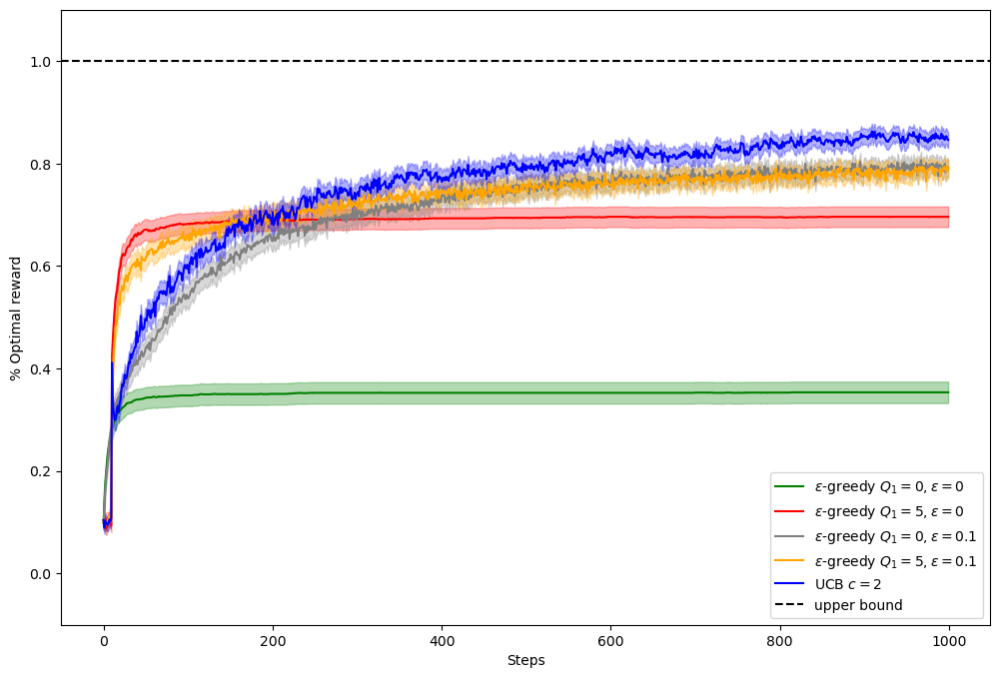

In [92]:
# Plot the "Average reward" figure
plot_curves([actions_a, actions_b, actions_c, actions_d, actions_u],
            [r"$\epsilon$-greedy $Q_1=0, \epsilon=0$",
             r"$\epsilon$-greedy $Q_1=5, \epsilon=0$",
             r"$\epsilon$-greedy $Q_1=0, \epsilon=0.1$",
             r"$\epsilon$-greedy $Q_1=5, \epsilon=0.1$",
             r"UCB $c=2$"],
            ["green", "red", "gray", "orange", "blue"],
            np.ones(time_step),
            "% Optimal reward")